Author: Derrick Chen (format based on a project by Anna Phyo & Derrick Chen)


Date: 06/15/2026

Modified Date: 07/28/2026

Description: This file contains the fully functional codes to train an air quality predicting model using Linear and Lasso Regressors, Stochastic Gradient Descent (SGD) Regressor, Gradient Boost with and without Linear hybrid, AdaBoost, Linear Support Vector Regression (SVR), Artificial Neural Network (ANN), Random Forest, and Ridge Regressor. XGBoost will also be used as an additional model. The code includes data fitting, training, & post-training analyses.

1. Importing the File

In [ ]:
import pandas as pd
import numpy as np

# Mounting the Drive
from google.colab import drive
drive.mount('/content/drive')

# Pathing to my file
file = "/content/drive/MyDrive/air_quality_global.csv"

Mounted at /content/drive


2. Reading the File

In [ ]:
df = pd.read_csv(file)

3. Using Three Methods to Explore the Data

In [ ]:
df.head()

,city,latitude,longitude,year,month,pm25_ugm3,no2_ugm3
0,New York,40.7128,-74.006,1999,1,18.11,35.98
1,New York,40.7128,-74.006,1999,2,27.79,17.71
2,New York,40.7128,-74.006,1999,3,12.05,40.99
3,New York,40.7128,-74.006,1999,4,35.25,17.18
4,New York,40.7128,-74.006,1999,5,38.39,25.07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       6480 non-null   object 
 1   latitude   6480 non-null   float64
 2   longitude  6480 non-null   float64
 3   year       6480 non-null   int64  
 4   month      6480 non-null   int64  
 5   pm25_ugm3  6480 non-null   float64
 6   no2_ugm3   6480 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 354.5+ KB


In [ ]:
df.describe()

,latitude,longitude,year,month,pm25_ugm3,no2_ugm3
count,6480.000000,6480.000000,6480.000000,6480.000000,6480.000000,6480.000000
mean,31.535510,-35.877325,2012.000000,6.500000,40.968210,39.617276
std,16.603137,81.511132,7.789482,3.452319,36.303963,16.711882
min,-23.550500,-121.886300,1999.000000,1.000000,5.100000,10.250000
25%,29.244100,-98.653500,2005.000000,3.750000,19.337500,27.080000
50%,33.750300,-74.585600,2012.000000,6.500000,29.225000,36.845000
75%,40.142650,5.885650,2019.000000,9.250000,46.080000,48.922500
max,52.520000,139.650300,2025.000000,12.000000,274.180000,110.270000


4. Plotting A Histogram for Each Numerical Attribute

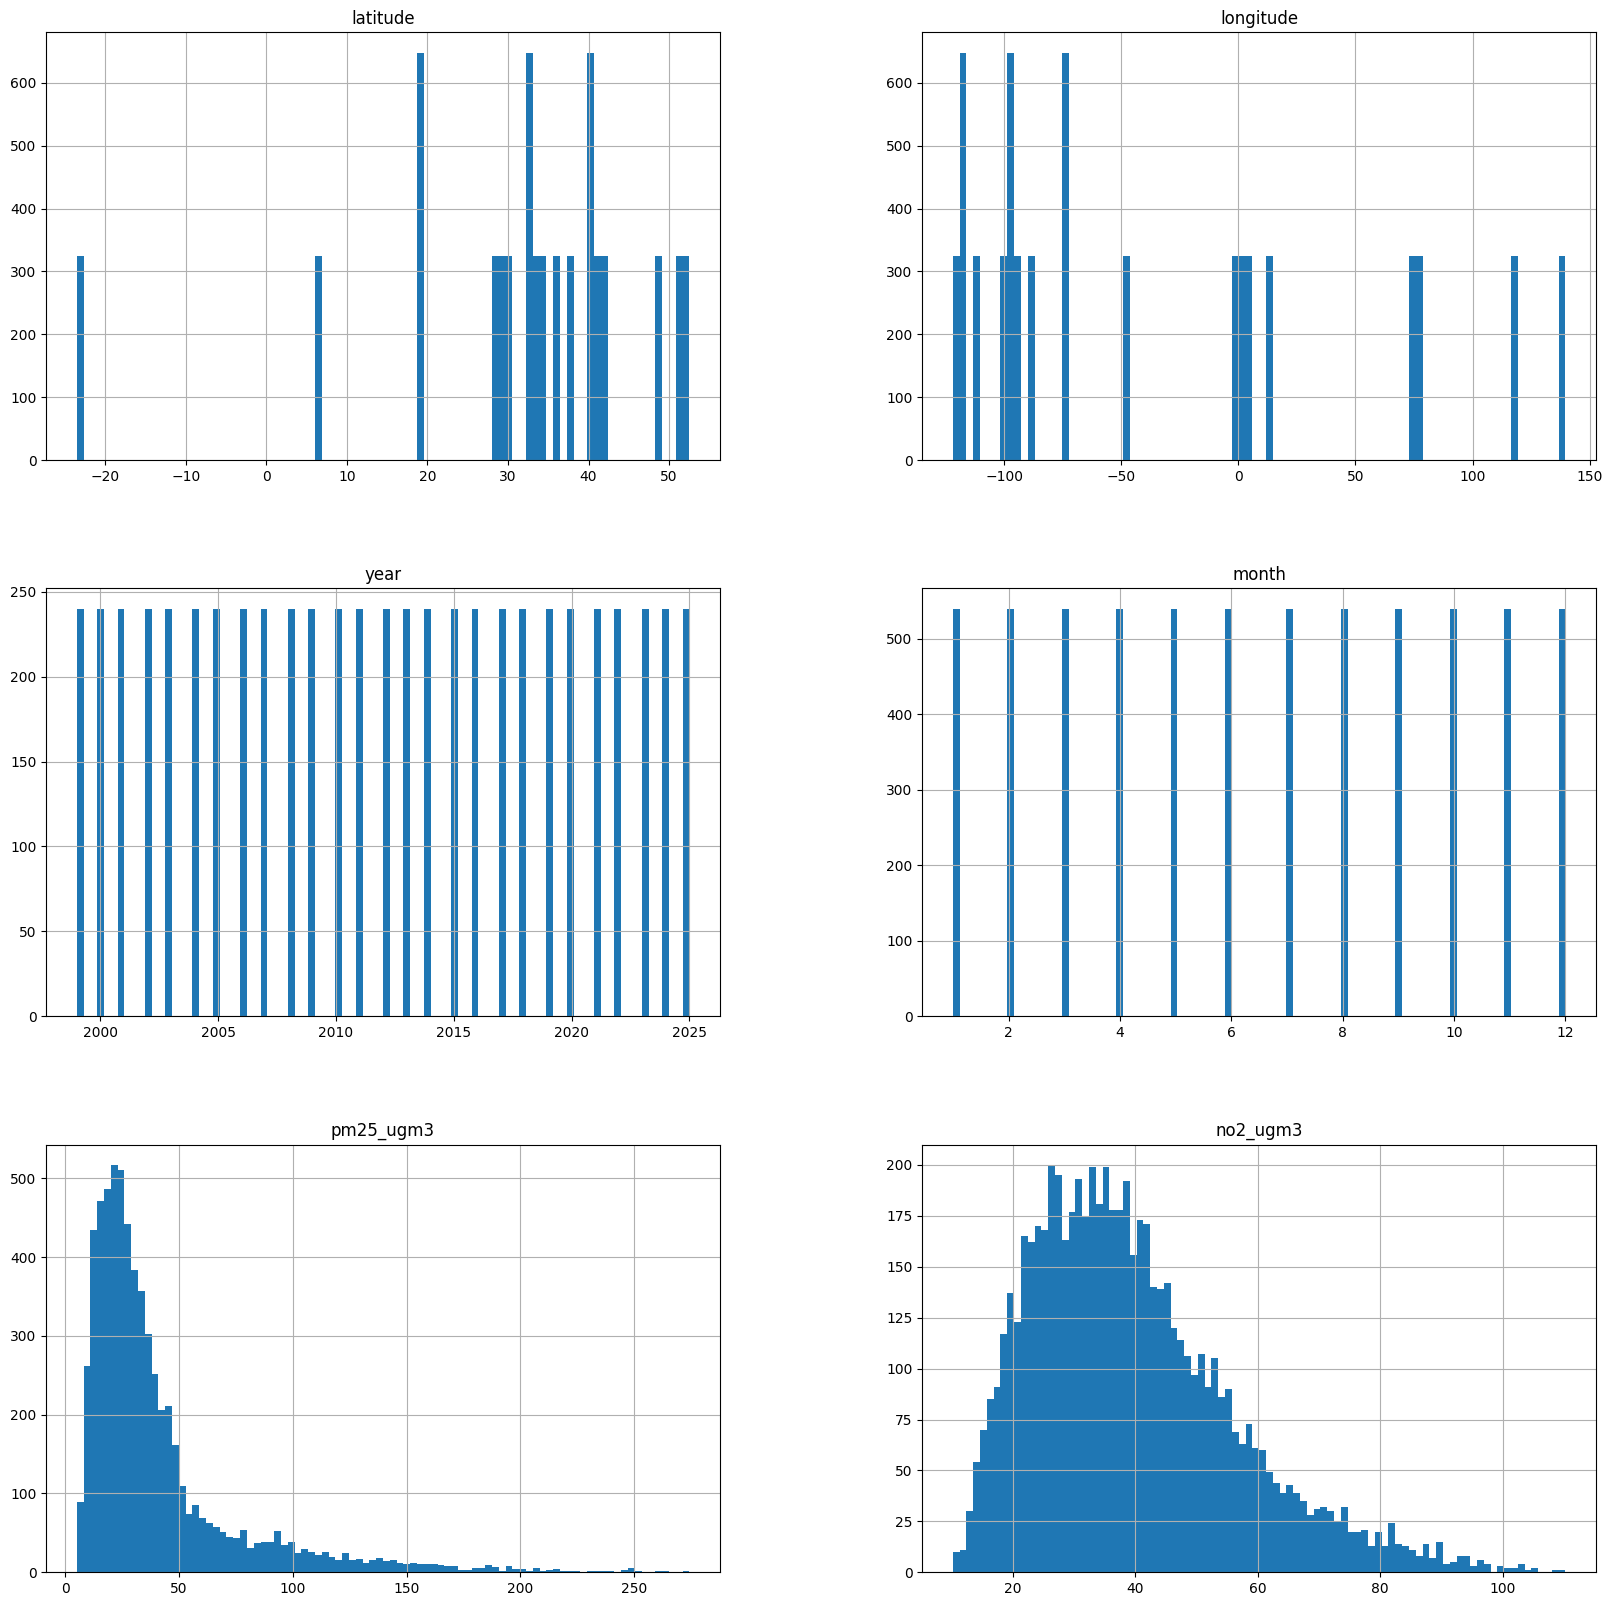

In [ ]:
import matplotlib.pyplot as plt

df.hist(bins=90, figsize=(20, 20))
plt.show()

Observations: Month, year, and location are irrelevant for the charts. The chart for pm25_ugm3 measures PM2.5, or airborne particles smaller than 2.5 micrometers such as dust, smoke, and soot, measured in micrograms per cubic meter, and it has has much higher values between 0 and 50 and decreases exponentially after 50. For no2_ugm3 or nitrogen dioxide measured by micrograms per cubic meter, it starts off fairly low before rapidly increasing and peaking between about 25-42, before graudally decreasing and reacing low levels around 100.

5. Plotting the Feature Correlation Matrix

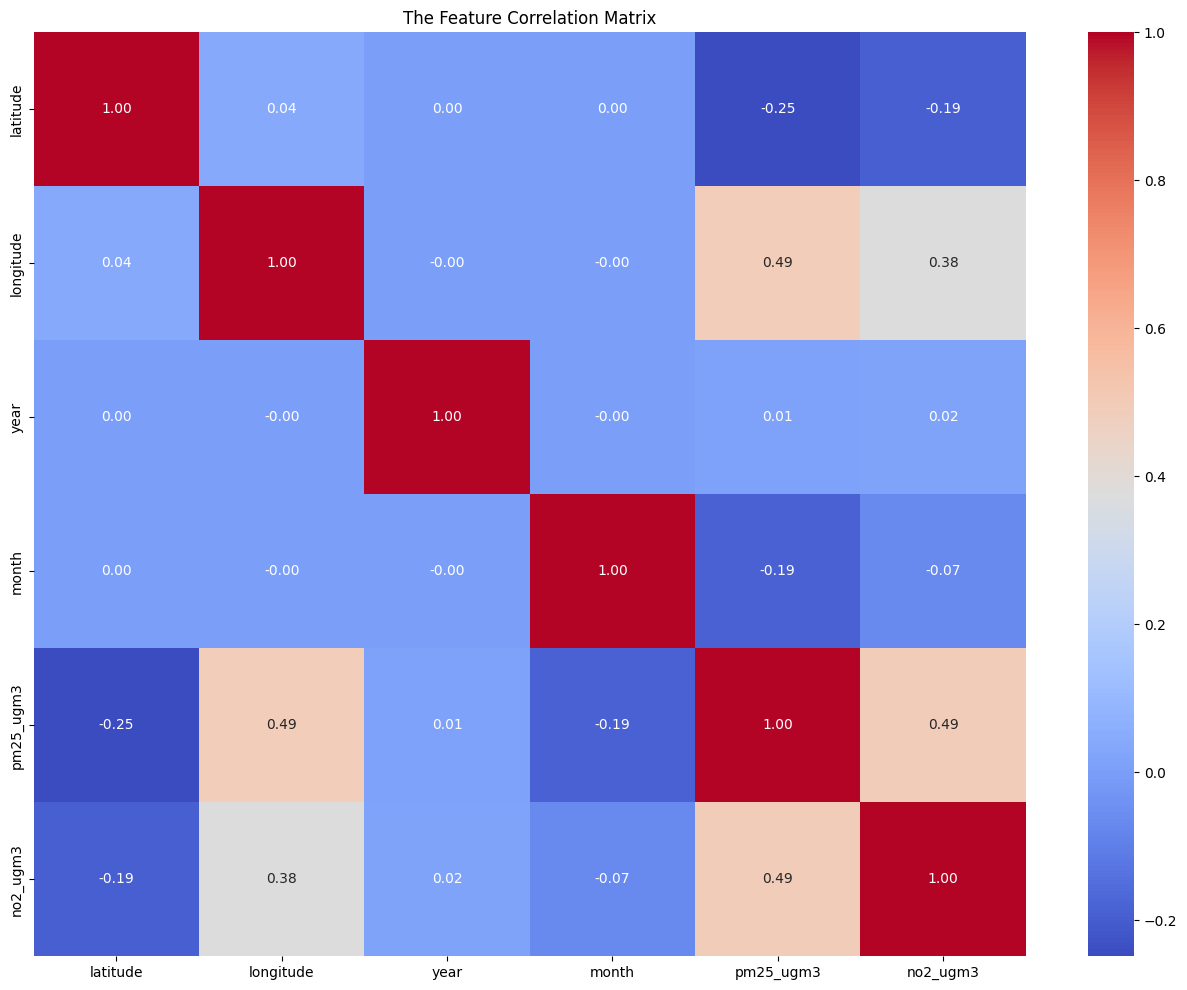

Correlations with pm25_ugm3:
 pm25_ugm3    1.000000
no2_ugm3     0.493411
longitude    0.490227
year         0.011645
month       -0.185689
latitude    -0.248877
Name: pm25_ugm3, dtype: float64
Correlations with no2_ugm3:
 no2_ugm3     1.000000
pm25_ugm3    0.493411
longitude    0.378240
year         0.019105
month       -0.067931
latitude    -0.190763
Name: no2_ugm3, dtype: float64

Top 5 positively correlated features with pm25_ugm3:
no2_ugm3     0.493411
longitude    0.490227
year         0.011645
month       -0.185689
latitude    -0.248877
Name: pm25_ugm3, dtype: float64

Top 5 negatively correlated features with pm25_ugm3:
no2_ugm3     0.493411
longitude    0.490227
year         0.011645
month       -0.185689
latitude    -0.248877
Name: pm25_ugm3, dtype: float64

Top 5 positively correlated features with no2_ugm3:
pm25_ugm3    0.493411
longitude    0.378240
year         0.019105
month       -0.067931
latitude    -0.190763
Name: no2_ugm3, dtype: float64

Top 5 negatively correlated

In [ ]:
import seaborn as sns

# Keep only numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Compute correlations
correlation_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("The Feature Correlation Matrix")
plt.show()

# Correlation with pm25_ugm3
target_corr = correlation_matrix['pm25_ugm3'].sort_values(ascending=False)
print("Correlations with pm25_ugm3:\n", target_corr)

# Correlation with no2_ugm3
target_corr2 = correlation_matrix['no2_ugm3'].sort_values(ascending=False)
print("Correlations with no2_ugm3:\n", target_corr2)

# Top 5 positive and negative correlations for pm25_ugm3 and no2_ugm3
print("\nTop 5 positively correlated features with pm25_ugm3:")
print(target_corr[1:6])  # skip self-correlation

print("\nTop 5 negatively correlated features with pm25_ugm3:")
print(target_corr[-5:])

print("\nTop 5 positively correlated features with no2_ugm3:")
print(target_corr2[1:6])  # skip self-correlation

print("\nTop 5 negatively correlated features with no2_ugm3:")
print(target_corr2[-5:])

Observations:

Top positive correlations:

- pm25_ugm3 has a moderate correlation with no2_ugm3, which makes sense due to being common air pollution but different types
-Longitude have moderate correlations with both pm25_ugm3 and no2_ugm3, which may be the locations of the measured cities so might not mean much

Top negative correlations:

- Latitude has weak negative correlations with pm25_ugm3 and no2_ugm3, I doubt that means much on its own but can identify cities and other sources


6. Sorting data by city, year and month

In [ ]:
df = df.sort_values(by=['city', 'year', 'month']).reset_index(drop=True)
df.head()

,city,latitude,longitude,year,month,pm25_ugm3,no2_ugm3
0,Beijing,39.9042,116.4074,1999,1,46.70,42.29
1,Beijing,39.9042,116.4074,1999,2,125.83,41.67
2,Beijing,39.9042,116.4074,1999,3,90.05,67.34
3,Beijing,39.9042,116.4074,1999,4,84.95,33.98
4,Beijing,39.9042,116.4074,1999,5,89.30,52.69


7. Creating AQ Score, Lag Features, Moving Averages, Rolling Averages and Cyclical Month Encoding

In [ ]:
from sklearn.preprocessing import StandardScaler

#AQ Score
aq_scaler = StandardScaler()
#Normalize pollutant values
df[['pm25_scaled', 'no2_scaled']] = aq_scaler.fit_transform(df[['pm25_ugm3', 'no2_ugm3']])
#Combined AQ Score
df['aq_score'] = (0.7 * df['pm25_scaled'] +0.3 * df['no2_scaled'])
df[['city', 'aq_score']].head()

,city,aq_score
0,Beijing,0.158509
1,Beijing,1.673253
2,Beijing,1.444148
3,Beijing,0.746902
4,Beijing,1.166679


In [ ]:
# Monthly Lag Features shift (shift parameter is month count)
df['aq_lag1'] = (df.groupby('city')['aq_score'].shift(1))
df['aq_lag3'] = (df.groupby('city')['aq_score'].shift(3))
df['aq_lag6'] = (df.groupby('city')['aq_score'].shift(6))
# Same month last year
df['aq_lag12'] = (df.groupby('city')['aq_score'].shift(12))

df.head(20)

,city,latitude,longitude,year,month,pm25_ugm3,no2_ugm3,pm25_scaled,no2_scaled,aq_score,aq_lag1,aq_lag3,aq_lag6,aq_lag12
0,Beijing,39.9042,116.4074,1999,1,46.70,42.29,0.157895,0.159942,0.158509,NaN,NaN,NaN,NaN
1,Beijing,39.9042,116.4074,1999,2,125.83,41.67,2.337716,0.122840,1.673253,0.158509,NaN,NaN,NaN
2,Beijing,39.9042,116.4074,1999,3,90.05,67.34,1.352072,1.658991,1.444148,1.673253,NaN,NaN,NaN
3,Beijing,39.9042,116.4074,1999,4,84.95,33.98,1.211581,-0.337347,0.746902,1.444148,0.158509,NaN,NaN
4,Beijing,39.9042,116.4074,1999,5,89.30,52.69,1.331412,0.782302,1.166679,0.746902,1.673253,NaN,NaN
5,Beijing,39.9042,116.4074,1999,6,94.54,63.24,1.475760,1.413638,1.457123,1.166679,1.444148,NaN,NaN
6,Beijing,39.9042,116.4074,1999,7,72.24,37.57,0.861454,-0.122514,0.566264,1.457123,0.746902,0.158509,NaN
7,Beijing,39.9042,116.4074,1999,8,101.86,42.98,1.677406,0.201233,1.234554,0.566264,1.166679,1.673253,NaN
8,Beijing,39.9042,116.4074,1999,9,28.60,63.05,-0.340711,1.402268,0.182183,1.234554,1.457123,1.444148,NaN
9,Beijing,39.9042,116.4074,1999,10,73.89,60.83,0.906907,1.269418,1.015660,0.182183,0.566264,0.746902,NaN


In [ ]:
#Moving Averages
df['aq_roll3'] = (df.groupby('city')['aq_score'].transform(lambda x: x.shift(1).rolling(3).mean()))

df['aq_roll6'] = (df.groupby('city')['aq_score'].transform(lambda x: x.shift(1).rolling(6).mean()))

df['aq_roll12'] = (df.groupby('city')['aq_score'].transform(lambda x: x.shift(1).rolling(12).mean()))

In [ ]:
#Rolling Averages
# 3-month rolling average
df['aq_roll3'] = (df.groupby('city')['aq_score'].rolling(3).mean().reset_index(level=0, drop=True))
# 12-month rolling average
df['aq_roll12'] = (df.groupby('city')['aq_score'].rolling(12).mean().reset_index(level=0, drop=True))

In [ ]:
#Cyclical month encoding
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

In [ ]:
#Remove missing rows
df = df.dropna().reset_index(drop=True)

Feature Engineering Correlation Matrix

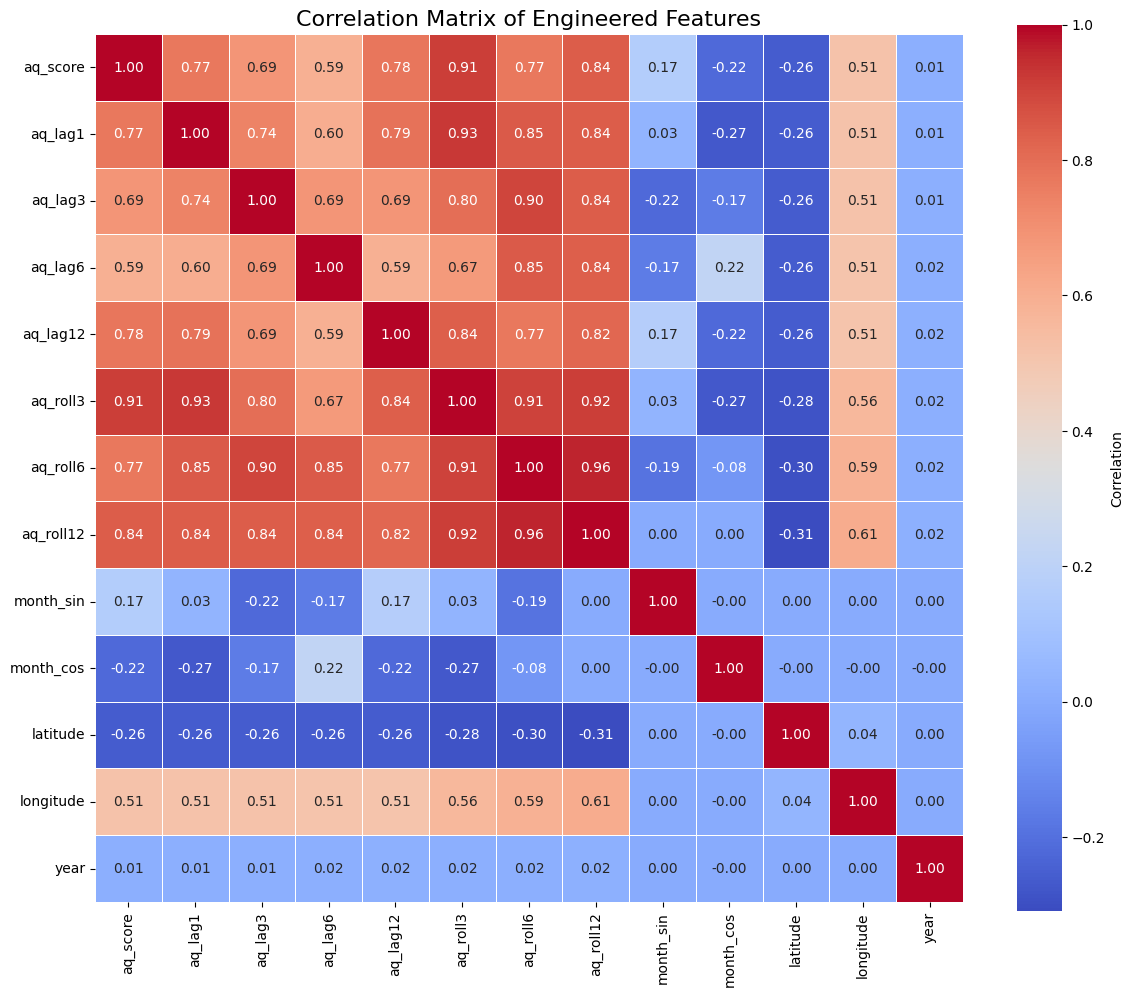

In [ ]:
# Select engineered features and target
corr_features = ['aq_score', 'aq_lag1', 'aq_lag3', 'aq_lag6', 'aq_lag12', 'aq_roll3', 'aq_roll6', 'aq_roll12', 'month_sin', 'month_cos', 'latitude', 'longitude', 'year']

# Keep only columns that exist in the dataframe
corr_features = [col for col in corr_features if col in df.columns]

# Correlation matrix
correlation_matrix = df[corr_features].corr()

# Plot heatmap
plt.figure(figsize=(12,10))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"label": "Correlation"})

plt.title("Correlation Matrix of Engineered Features", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation with AQ Score
aq_corr = correlation_matrix['aq_score'].sort_values(ascending=False)

print("Correlation with AQ Score:\n")
print(aq_corr)# Correlation with AQ Score
aq_corr = correlation_matrix['aq_score'].sort_values(ascending=False)

print("Correlation with AQ Score:\n")
print(aq_corr)

Correlation with AQ Score:

aq_score     1.000000
aq_roll3     0.914099
aq_roll12    0.843384
aq_lag12     0.778771
aq_lag1      0.774109
aq_roll6     0.771028
aq_lag3      0.687771
aq_lag6      0.594548
longitude    0.514884
month_sin    0.165511
year         0.014911
month_cos   -0.219496
latitude    -0.260640
Name: aq_score, dtype: float64
Correlation with AQ Score:

aq_score     1.000000
aq_roll3     0.914099
aq_roll12    0.843384
aq_lag12     0.778771
aq_lag1      0.774109
aq_roll6     0.771028
aq_lag3      0.687771
aq_lag6      0.594548
longitude    0.514884
month_sin    0.165511
year         0.014911
month_cos   -0.219496
latitude    -0.260640
Name: aq_score, dtype: float64


In [ ]:
print("Top 5 Positively Correlated Features with AQ Score")
print(aq_corr[1:6])     # Skip self-correlation

print("\nTop 5 Negatively Correlated Features with AQ Score")
print(aq_corr.tail(5))

Top 5 Positively Correlated Features with AQ Score
aq_roll3     0.914099
aq_roll12    0.843384
aq_lag12     0.778771
aq_lag1      0.774109
aq_roll6     0.771028
Name: aq_score, dtype: float64

Top 5 Negatively Correlated Features with AQ Score
longitude    0.514884
month_sin    0.165511
year         0.014911
month_cos   -0.219496
latitude    -0.260640
Name: aq_score, dtype: float64


8. Splitting Datasets into Training, Validation and Test Sets

In [ ]:
train_df = df[df["year"] <= 2021]
val_df = df[df["year"] == 2022]
test_df = df[df["year"] >= 2023]

9. Separating Features and Target

In [ ]:
features = ['city', 'year', 'month_sin', 'month_cos', 'latitude', 'longitude', 'aq_lag1', 'aq_lag3', 'aq_lag6', 'aq_lag12', 'aq_roll3', 'aq_roll6', 'aq_roll12']

X_train = train_df[features]
y_train = train_df['aq_score']

X_val = val_df[features]
y_val = val_df['aq_score']

X_test = test_df[features]
y_test = test_df['aq_score']

In [ ]:
#One-Hot Encoding to include City
X_train = pd.get_dummies(X_train, columns=['city'], drop_first=True)
X_val = pd.get_dummies(X_val, columns=['city'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['city'], drop_first=True)

# Make validation/test match the training columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

Note: 'pm25_ugm3' and 'no2_ugm3' were removed to prevent data leakage because they were included in the AQ scores

10. Checking Whether the Training Set Has the Correct Features

In [ ]:
print(X_train.columns)
print(X_train.shape)
print(y_train.shape)

Index(['year', 'month_sin', 'month_cos', 'latitude', 'longitude', 'aq_lag1',
       'aq_lag3', 'aq_lag6', 'aq_lag12', 'aq_roll3', 'aq_roll6', 'aq_roll12',
       'city_Berlin', 'city_Chicago', 'city_Dallas', 'city_Delhi',
       'city_Houston', 'city_Lagos', 'city_London', 'city_Los Angeles',
       'city_Mexico City', 'city_Mumbai', 'city_New York', 'city_Paris',
       'city_Philadelphia', 'city_Phoenix', 'city_San Antonio',
       'city_San Diego', 'city_San Jose', 'city_São Paulo', 'city_Tokyo'],
      dtype='object')
(5280, 31)
(5280,)


11. Scaling Features for Linear & Lasso Regressors, SGD Regressor, Linear Support Vector Regression (SVR), and Artificial Neural Network (MLP Regressor)

In [ ]:
scaler  = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

12. Training the Model Using the Linear Regression to Handle Linear Relationships

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
train_pred_lr = lr_model.predict(X_train_scaled)
val_pred_lr = lr_model.predict(X_val_scaled)
test_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression trained successfully.")
print(f"Train MAE:  {mean_absolute_error(y_train, train_pred_lr):.4f}")
print(f"Validation MAE:  {mean_absolute_error(y_val, val_pred_lr):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, test_pred_lr):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred_lr)):.4f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_pred_lr)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred_lr)):.4f}")
print(f"Train R squared:   {r2_score(y_train, train_pred_lr):.4f}")
print(f"Validation R squared:   {r2_score(y_val, val_pred_lr):.4f}")
print(f"Test R squared:   {r2_score(y_test, test_pred_lr):.4f}")

Linear Regression trained successfully.
Train MAE:  0.1740
Validation MAE:  0.1838
Test MAE:  0.1632
Train RMSE: 0.2492
Validation RMSE: 0.2527
Test RMSE: 0.2298
Train R squared:   0.9216
Validation R squared:   0.9151
Test R squared:   0.9334


Linear Regression Optimization

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

# Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# Pipeline: Feature Selection + Linear Regression
lr_pipeline = Pipeline([
    ("feature_selection", RFECV(
        estimator=LinearRegression(),
        step=1,
        cv=tscv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )),
    ("regressor", LinearRegression())
])

# Training the Optimized Model
lr_pipeline.fit(X_train_scaled, y_train)

# Predictions
train_pred_lrO = lr_pipeline.predict(X_train_scaled)
val_pred_lrO = lr_pipeline.predict(X_val_scaled)
test_pred_lrO = lr_pipeline.predict(X_test_scaled)

print("Optimized Linear Regression trained successfully.")
print(f"Train MAE:  {mean_absolute_error(y_train, train_pred_lrO):.4f}")
print(f"Validation MAE:  {mean_absolute_error(y_val, val_pred_lrO):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, test_pred_lrO):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred_lrO)):.4f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_pred_lrO)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred_lrO)):.4f}")
print(f"Train R squared:   {r2_score(y_train, train_pred_lrO):.4f}")
print(f"Validation R squared:   {r2_score(y_val, val_pred_lrO):.4f}")
print(f"Test R squared:   {r2_score(y_test, test_pred_lrO):.4f}")

Optimized Linear Regression trained successfully.
Train MAE:  0.1740
Validation MAE:  0.1836
Test MAE:  0.1632
Train RMSE: 0.2493
Validation RMSE: 0.2525
Test RMSE: 0.2298
Train R squared:   0.9216
Validation R squared:   0.9152
Test R squared:   0.9335


Observations:

The predicted values for both regression models are practically on the dot given MAE and RMSE being very low, which suggests overfitting or data leakage. Air quality predictions isn't something where linear regression would be good at due to the nature of the data.

Observations after fixing data leakage: The MAE, RMSE and R squared are much more realistic now. Across all three areas for training, validation and test, the MAE and RMSE remain low and R squared is high but not by too much to suggest data leakage. Now it's a solid model as the differences between the three area scores are small.

Showing the Selected Features After Optimization

In [ ]:
selected = lr_pipeline.named_steps["feature_selection"].support_

print("Selected Features:")
print(X_train.columns[selected])

Selected Features:
Index(['month_sin', 'month_cos', 'aq_lag1', 'aq_lag3', 'aq_lag6', 'aq_lag12',
       'aq_roll3', 'aq_roll6', 'aq_roll12'],
      dtype='object')


Computing Residuals

In [ ]:
# Residuals = actual - predicted
train_residuals = y_train - train_pred_lr
val_residuals = y_val - val_pred_lr
test_residuals = y_test - test_pred_lr

Training the AdaBoosting Regressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Weak learner
base_tree = DecisionTreeRegressor(max_depth=3)

ada_model = AdaBoostRegressor(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(X_train_scaled, train_residuals)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3),
                  learning_rate=0.05, n_estimators=100, random_state=42)

Predicting Residuals

In [ ]:
train_residual_pred = ada_model.predict(X_train_scaled)
val_residual_pred = ada_model.predict(X_val_scaled)
test_residual_pred = ada_model.predict(X_test_scaled)

Final Predictions

In [ ]:
train_final_ada = train_pred_lr + train_residual_pred
val_final_ada = val_pred_lr + val_residual_pred
test_final_ada = test_pred_lr + test_residual_pred

Evaluating the Linear + AdaBoost Model

In [ ]:
def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

print("\nHybrid Model: Linear Regression + AdaBoost")

print("Train RMSE:", rmse(y_train, train_final_ada))
print("Validation RMSE:", rmse(y_val, val_final_ada))
print("Test RMSE:", rmse(y_test, test_final_ada))


Hybrid Model: Linear Regression + AdaBoost
Train RMSE: 0.24599894405719003
Validation RMSE: 0.25277161129345116
Test RMSE: 0.22980354750910617


Observations: The hybrid Linear Regression model combined with AdaBoost had little effect on performance since all 3 RMSE's remain miniscule, which is to be expected since linear regression isn't as good of a fit for this dataset even if it's not bad

Training the GradientBoosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8, # helps reduce overfitting
    random_state=42
)

gbr_model.fit(X_train_scaled, train_residuals)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42,
                          subsample=0.8)

Predicting Residuals

In [ ]:
train_residual_pred = gbr_model.predict(X_train_scaled)
val_residual_pred = gbr_model.predict(X_val_scaled)
test_residual_pred = gbr_model.predict(X_test_scaled)

Final Predictions

In [ ]:
train_final_gb = train_pred_lr + train_residual_pred
val_final_gb = val_pred_lr + val_residual_pred
test_final_gb = test_pred_lr + test_residual_pred

Evaluating the Linear + GradientBoosting Model

In [ ]:
def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

print("\nHybrid Model: Linear Regression + Gradient Boosting")

print("Train RMSE:", rmse(y_train, train_final_gb))
print("Validation RMSE:", rmse(y_val, val_final_gb))
print("Test RMSE:", rmse(y_test, test_final_gb))


Hybrid Model: Linear Regression + Gradient Boosting
Train RMSE: 0.2139407885246698
Validation RMSE: 0.2578901891304028
Test RMSE: 0.23246580950829976


Observations: The hybrid model incorporating Gradient Boosting achieved similar results yet again, since RMSE's that low wouldn't benefit much from boosting; again due to not fitting linear regression very well

Plotting the Hybrid Model vs Actual Values on Test Set

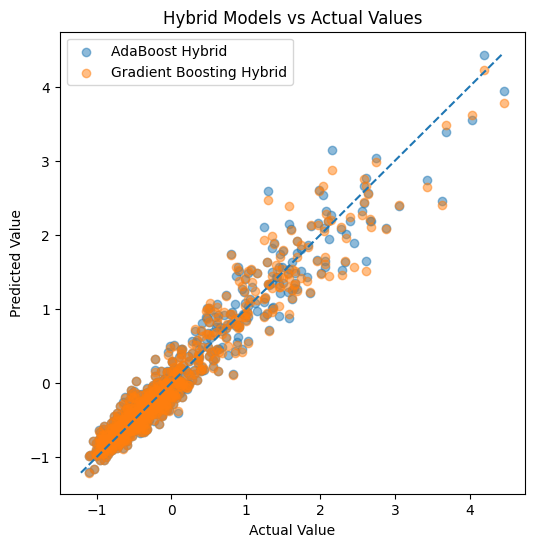

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, test_final_ada, alpha=0.5, label="AdaBoost Hybrid")
plt.scatter(y_test, test_final_gb, alpha=0.5, label="Gradient Boosting Hybrid")

# Perfect prediction line
min_val = min(y_test.min(), test_final_ada.min(), test_final_gb.min())
max_val = max(y_test.max(), test_final_ada.max(), test_final_gb.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Hybrid Models vs Actual Values")
plt.legend()

plt.show()

Observations:
The plot shows that the predictions, especially that of the hybrid Linear Regression-AdaBoost model are very close to the actual prices, showing high accuracy and low error, expected from predictions with very low RMSE's

Post Data leak fix: The plot looks a lot better now, the data remains close but much more scattered especially as the values increase, this shows that hte predictions are pretty close for the most part

Plotting the Model Comparison

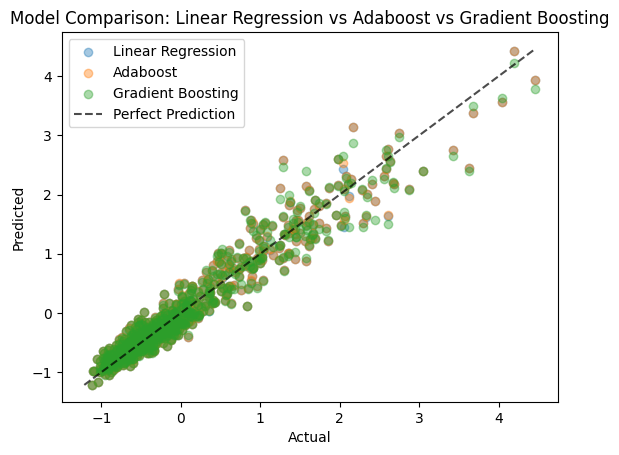

In [ ]:
# Scatter plots for Linear Regression, Adaboost, and Gradient Boosting
plt.scatter(y_test, test_pred_lr, alpha=0.4, label="Linear Regression")
plt.scatter(y_test, test_final_ada, alpha=0.4, label="Adaboost")
plt.scatter(y_test, test_final_gb, alpha=0.4, label="Gradient Boosting")

# Perfect prediction line
min_val = min(y_test.min(), test_pred_lr.min(), test_final_ada.min(), test_final_gb.min())
max_val = max(y_test.max(), test_pred_lr.max(), test_final_ada.max(), test_final_gb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label="Perfect Prediction")

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison: Linear Regression vs Adaboost vs Gradient Boosting")
plt.show()

Observations:
This shows the models have similar performances and reinforce the general qualities of Linear Regression here

13. Training the Model Using the Lasso Regression to Featuring Selections

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01, max_iter=20000)
lasso_model.fit(X_train_scaled, y_train)

train_pred_lasso = lasso_model.predict(X_train_scaled)
val_pred_lasso = lasso_model.predict(X_val_scaled)
test_pred_lasso = lasso_model.predict(X_test_scaled)

Lasso Regression Optimization (Alpha Tuning)

In [ ]:
from sklearn.linear_model import Lasso

# Different alpha values to test
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1]

results = []

print("Lasso Regression Hyperparameter Tuning\n")

for alpha in alpha_values:

    # Creating model
    lasso_model = Lasso(alpha=alpha, max_iter=20000)

    # Training model
    lasso_model.fit(X_train_scaled, y_train)

    # Predictions
    train_pred_lasso = lasso_model.predict(X_train_scaled)
    val_pred_lasso = lasso_model.predict(X_val_scaled)
    test_pred_lasso = lasso_model.predict(X_test_scaled)

    # MAE calculation
    train_mae = mean_squared_error(y_train, train_pred_lasso)
    val_mae = mean_squared_error(y_val, val_pred_lasso)
    test_mae = mean_squared_error(y_test, test_pred_lasso)

    # RMSE calculations
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_lasso))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_lasso))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_lasso))

    # Storing results
    results.append([alpha, train_mae, val_mae, test_mae, train_rmse, val_rmse, test_rmse])

    # Printing results
    print(f"Alpha: {alpha}")
    print(f"Train MAE: {train_mae}")
    print(f"Validation MAE: {val_mae}")
    print(f"Test MAE: {test_mae}")
    print(f"Train RMSE: {train_rmse}")
    print(f"Validation RMSE: {val_rmse}")
    print(f"Test RMSE: {test_rmse}")
    print("-----------------------------")

# Convert results to dataframe for easy viewing
results_df = pd.DataFrame(results, columns=["Alpha", "Train MAE", "Validation MAE", "Test MAE", "Train RMSE", "Validation RMSE", "Test RMSE"])

print("\nSummary of Lasso Optimization:")
print(results_df)

Lasso Regression Hyperparameter Tuning

Alpha: 0.0001
Train MAE: 0.06212818118693584
Validation MAE: 0.06389269782089585
Test MAE: 0.05281902778315159
Train RMSE: 0.24925525307791577
Validation RMSE: 0.25277004929559166
Test RMSE: 0.22982390603057723
-----------------------------
Alpha: 0.001
Train MAE: 0.062361097744473085
Validation MAE: 0.0646931103898457
Test MAE: 0.053123705917845716
Train RMSE: 0.24972204096649755
Validation RMSE: 0.2543484035527758
Test RMSE: 0.2304858041568845
-----------------------------
Alpha: 0.01
Train MAE: 0.07808820969507094
Validation MAE: 0.08233237691096358
Test MAE: 0.06611314867604019
Train RMSE: 0.2794426769394234
Validation RMSE: 0.2869361896153282
Test RMSE: 0.2571247725833514
-----------------------------
Alpha: 0.1
Train MAE: 0.13698527291738863
Validation MAE: 0.13032260871015341
Test MAE: 0.11983333399747173
Train RMSE: 0.37011521573341
Validation RMSE: 0.3610022281235303
Test RMSE: 0.3461695162741395
-----------------------------
Alpha: 1
Tr

Observations:

The Lasso regression results show that as the regularization parameter alpha increases, the training, validation, and test RMSE all rise, indicating that stronger regularization reduces the model’s ability to fit the data. Even at the smallest alpha (0.0001), Lasso’s performance (Test RMSE ≈ 0.000201) is worse than that of Linear Regression (Test RMSE ≈ 2.465481663247455e-16) but still close, suggesting it doesn't have the problems as Linear Regression where it fits better for the dataset. MAE follows a similar trend

After fixing data leak: There's a overall similar trend to before but the values are still small but fixed, indicating good performance overall at the best alpha value which remains the same.

Plotting the Lasso Alpha Optimization

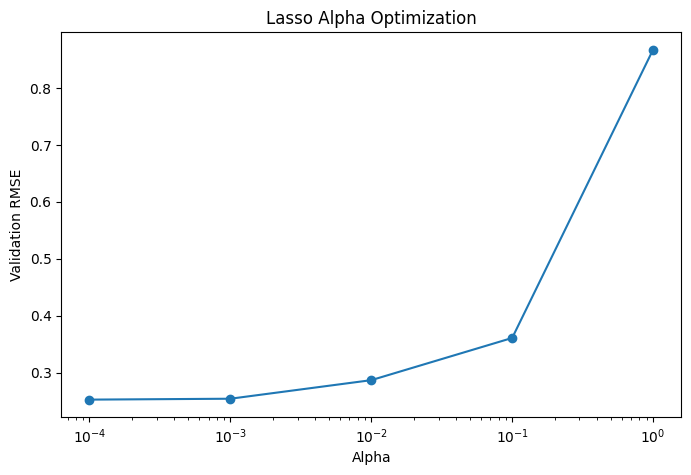

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results_df["Alpha"], results_df["Validation RMSE"], marker='o')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Validation RMSE")
plt.title("Lasso Alpha Optimization")
plt.show()

14. Training the Model Using the Random Forest to Handle Complex and Non-linear Relationships

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42
)

# Fit model
rf_model.fit(X_train, y_train)

# Predict
train_pred_rf = rf_model.predict(X_train)
val_pred_rf = rf_model.predict(X_val)
test_pred_rf = rf_model.predict(X_test)

# Evaluate
print("\nRandom Forest Regressor")
print(f"Train MAE: {mean_absolute_error(y_train, train_pred_rf):.4f}")
print(f"Val MAE: {mean_absolute_error(y_val, val_pred_rf):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_pred_rf):.4f}")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_rf)))
print("Val RMSE:", np.sqrt(mean_squared_error(y_val, val_pred_rf)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_rf)))
print(f"Train R squared:   {r2_score(y_train, train_pred_rf):.4f}")
print(f"Validation R squared:   {r2_score(y_val, val_pred_rf):.4f}")
print(f"Test R squared:   {r2_score(y_test, test_pred_rf):.4f}")


Random Forest Regressor
Train MAE: 0.2681
Val MAE: 0.2732
Test MAE: 0.2630
Train RMSE: 0.37293455281932175
Val RMSE: 0.36916543602914825
Test RMSE: 0.3546601279513163
Train R squared:   0.8245
Validation R squared:   0.8187
Test R squared:   0.8414


Observations: The model performs pretty well on the datasets, with all RMSE's being aroumd 0.2, the MAE's being within 0.1 of each other and the R squared values being even closer, which means the predictions are pretty accurate. The R squared values are lower than Linear and Lasso Regressions and the RMSE's are higher, but they're still considered good overall.

15. Training the Model Using the Stochastic Gradient Descent (SGD) Regressor

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.0001,
    max_iter=2000,
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

# Predictions
train_pred_sgd = sgd_model.predict(X_train_scaled)
val_pred_sgd = sgd_model.predict(X_val_scaled)
test_pred_sgd = sgd_model.predict(X_test_scaled)

print("\nSGD Regressor")
print(f"Train MAE: {mean_absolute_error(y_train, train_pred_sgd):.4f}")
print(f"Val MAE: {mean_absolute_error(y_val, val_pred_sgd):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_pred_sgd):.4f}")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_sgd)))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_pred_sgd)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_sgd)))
print(f"Train R squared:   {r2_score(y_train, train_pred_sgd):.4f}")
print(f"Validation R squared:   {r2_score(y_val, val_pred_sgd):.4f}")
print(f"Test R squared:   {r2_score(y_test, test_pred_sgd):.4f}")


SGD Regressor
Train MAE: 0.1838
Val MAE: 0.1967
Test MAE: 0.1749
Train RMSE: 0.26381445747081156
Validation RMSE: 0.27132073201885953
Test RMSE: 0.24458657753509128
Train R squared:   0.9122
Validation R squared:   0.9021
Test R squared:   0.9246


Observations: Performance is solid with lower MAE and RMSE's and R squared closer to 1 than random forest regressor while also not being super low like linear regression, this is the best performing model so far.

SGD Regressor Optimization (Alpha and Penalities)

In [ ]:
from sklearn.linear_model import SGDRegressor

alpha_values = [0.00001, 0.0001, 0.001]
penalties = ["l2", "l1"]

results_sgd = []

print("SGD Regressor Hyperparameter Tuning\n")

for alpha in alpha_values:
    for penalty in penalties:

        sgd_model = SGDRegressor(
            loss="squared_error",
            penalty=penalty,
            alpha=alpha,
            max_iter=5000,
            random_state=42
        )

        sgd_model.fit(X_train_scaled, y_train)

        # Predictions
        train_pred_sgdo = sgd_model.predict(X_train_scaled)
        val_pred_sgdo = sgd_model.predict(X_val_scaled)
        test_pred_sgdo = sgd_model.predict(X_test_scaled)

        # MAE calculation
        train_mae = mean_squared_error(y_train, train_pred_sgdo)
        val_mae = mean_squared_error(y_val, val_pred_sgdo)
        test_mae = mean_squared_error(y_test, test_pred_sgdo)

        # RMSE
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_sgdo))
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_sgdo))
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_sgdo))

        results_sgd.append([alpha, penalty, train_mae, val_mae, test_mae, train_rmse, val_rmse, test_rmse])

        print(f"Alpha: {alpha}, Penalty: {penalty}")
        print(f"Train MAE: {train_mae}")
        print(f"Validation MAE: {val_mae}")
        print(f"Test MAE: {test_mae}")
        print(f"Train RMSE: {train_rmse}")
        print(f"Validation RMSE: {val_rmse}")
        print(f"Test RMSE: {test_rmse}")
        print("-----------------------------")

# Summary table
sgd_results_df = pd.DataFrame(
    results_sgd,
    columns=["Alpha", "Penalty", "Train MAE", "Validation MAE", "Test MAE", "Train RMSE", "Validation RMSE", "Test RMSE"]
)

print("\nSGD Optimization Results")
print(sgd_results_df)

SGD Regressor Hyperparameter Tuning

Alpha: 1e-05, Penalty: l2
Train MAE: 0.06955124865945209
Validation MAE: 0.07355862087801296
Test MAE: 0.059779549354868934
Train RMSE: 0.2637257072404055
Validation RMSE: 0.2712169258693361
Test RMSE: 0.24449856718367274
-----------------------------
Alpha: 1e-05, Penalty: l1
Train MAE: 0.06955086471844431
Validation MAE: 0.07356933408469826
Test MAE: 0.05976701327071028
Train RMSE: 0.26372497932210426
Validation RMSE: 0.2712366754048911
Test RMSE: 0.24447292952535724
-----------------------------
Alpha: 0.0001, Penalty: l2
Train MAE: 0.06959806797061864
Validation MAE: 0.0736149396232498
Test MAE: 0.05982259391032922
Train RMSE: 0.26381445747081156
Validation RMSE: 0.27132073201885953
Test RMSE: 0.24458657753509128
-----------------------------
Alpha: 0.0001, Penalty: l1
Train MAE: 0.06958983743952821
Validation MAE: 0.07375319848722155
Test MAE: 0.059824570201728676
Train RMSE: 0.26379885791930224
Validation RMSE: 0.2715754011084611
Test RMSE: 0.

Observations:

Hyperparameter tuning was performed on the SGD Regressor by testing different values of alpha and penalty terms. The best-performing configuration (alpha = 0.001, penalty = L1) achieved a test RMSE of 0.012507, which is lower than the Random Forest model's test RMSE of 0.2038167 and a small but noticable upgrade from the unoptimized SGD Regressor's test RMSE of 0.014169598, and a similar trend of the three MAE values and their differences. This indicates that air quality trends in a global sense aren't linear and more unpredicatble.

16. Training the Model Using the Linear Support Vector Regression (SVR)

In [ ]:
from sklearn.svm import LinearSVR

svr_model = LinearSVR(
    C=1.0,
    epsilon=0.1,
    max_iter=5000,
    random_state=42
)

svr_model.fit(X_train_scaled, y_train)

train_pred_svr = svr_model.predict(X_train_scaled)
val_pred_svr = svr_model.predict(X_val_scaled)
test_pred_svr = svr_model.predict(X_test_scaled)

print("\nLinear SVR")
print(f"Train MAE: {mean_absolute_error(y_train, train_pred_svr):.4f}")
print(f"Val MAE: {mean_absolute_error(y_val, val_pred_svr):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_pred_svr):.4f}")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_svr)))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_pred_svr)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_svr)))
print(f"Train R squared:   {r2_score(y_train, train_pred_svr):.4f}")
print(f"Validation R squared:   {r2_score(y_val, val_pred_svr):.4f}")
print(f"Test R squared:   {r2_score(y_test, test_pred_svr):.4f}")


Linear SVR
Train MAE: 0.1740
Val MAE: 0.1840
Test MAE: 0.1632
Train RMSE: 0.249615715875656
Validation RMSE: 0.2535818760644169
Test RMSE: 0.23036981142597707
Train R squared:   0.9214
Validation R squared:   0.9145
Test R squared:   0.9331


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Observations: The model generalizes reasonably well, better than Random Forest but not as good as SGD Regressor regardless of optimalization

Linear SVR Optimization (C and Epsilon)

In [ ]:
from sklearn.svm import LinearSVR

# Hyperparameter values to test
C_values = [0.01, 0.1, 1, 10]
epsilon_values = [0.01, 0.1, 0.5]

results_svr = []

print("Linear SVR Hyperparameter Tuning\n")

for C in C_values:
    for eps in epsilon_values:

        svr_model = LinearSVR(
            C=C,
            epsilon=eps,
            max_iter=5000,
            random_state=42
        )

        svr_model.fit(X_train_scaled, y_train)

        # Predictions
        train_pred_svro = svr_model.predict(X_train_scaled)
        val_pred_svro = svr_model.predict(X_val_scaled)
        test_pred_svro = svr_model.predict(X_test_scaled)

        # MAE calculation
        train_mae = mean_squared_error(y_train, train_pred_svro)
        val_mae = mean_squared_error(y_val, val_pred_svro)
        test_mae = mean_squared_error(y_test, test_pred_svro)

        # RMSE
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_svro))
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_svro))
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_svro))

        results_svr.append([C, eps, train_mae, val_mae, test_mae, train_rmse, val_rmse, test_rmse])

        print(f"C: {C}, Epsilon: {eps}")
        print(f"Train MAE: {train_mae}")
        print(f"Validation MAE: {val_mae}")
        print(f"Test MAE: {test_mae}")
        print(f"Train RMSE: {train_rmse}")
        print(f"Validation RMSE: {val_rmse}")
        print(f"Test RMSE: {test_rmse}")
        print("-----------------------------")

# Summary table
svr_results_df = pd.DataFrame(
    results_svr,
    columns=["C", "Epsilon", "Train MAE", "Validation MAE", "Test MAE", "Train RMSE", "Validation RMSE", "Test RMSE"]
)

print("\nLinear SVR Optimization Results")
print(svr_results_df)

Linear SVR Hyperparameter Tuning

C: 0.01, Epsilon: 0.01
Train MAE: 0.06665948579472285
Validation MAE: 0.07101387223733578
Test MAE: 0.05702247308908947
Train RMSE: 0.2581849836739597
Validation RMSE: 0.2664842814076203
Test RMSE: 0.23879378779417498
-----------------------------
C: 0.01, Epsilon: 0.1
Train MAE: 0.06686354243668331
Validation MAE: 0.07099329271827533
Test MAE: 0.05690896420457549
Train RMSE: 0.2585798569817133
Validation RMSE: 0.2664456656023425
Test RMSE: 0.23855599804778643
-----------------------------
C: 0.01, Epsilon: 0.5
Train MAE: 0.08830099201802495
Validation MAE: 0.09323362667869271
Test MAE: 0.07595118057068886
Train RMSE: 0.2971548283606123
Validation RMSE: 0.305341819406862
Test RMSE: 0.27559241747676744
-----------------------------
C: 0.1, Epsilon: 0.01
Train MAE: 0.06228853713874268
Validation MAE: 0.06439055394299643
Test MAE: 0.05293996798708517
Train RMSE: 0.24957671593869224
Validation RMSE: 0.2537529387869162
Test RMSE: 0.2300868705230378
--------

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C: 1, Epsilon: 0.01
Train MAE: 0.06230509035210089
Validation MAE: 0.064269960218138
Test MAE: 0.053001181387559534
Train RMSE: 0.24960987631121667
Validation RMSE: 0.2535152070747197
Test RMSE: 0.23021985445994778
-----------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C: 1, Epsilon: 0.1
Train MAE: 0.06230800561211623
Validation MAE: 0.06430376786834929
Test MAE: 0.05307025001644023
Train RMSE: 0.249615715875656
Validation RMSE: 0.2535818760644169
Test RMSE: 0.23036981142597707
-----------------------------


...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C: 10, Epsilon: 0.01
Train MAE: 0.0630811070703817
Validation MAE: 0.06541490325337057
Test MAE: 0.05399162806882632
Train RMSE: 0.2511595251436459
Validation RMSE: 0.255763373557221
Test RMSE: 0.2323609865464216
-----------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C: 10, Epsilon: 0.1
Train MAE: 0.06337483590974613
Validation MAE: 0.06397105256011835
Test MAE: 0.05386601707651078
Train RMSE: 0.2517435915961837
Validation RMSE: 0.25292499394112544
Test RMSE: 0.23209053637860977
-----------------------------
C: 10, Epsilon: 0.5
Train MAE: 0.06724330024790197
Validation MAE: 0.06853103939471185
Test MAE: 0.05813199654986211
Train RMSE: 0.2593131316534162
Validation RMSE: 0.261784337565699
Test RMSE: 0.24110577875667374
-----------------------------

Linear SVR Optimization Results
        C  Epsilon  Train MAE  Validation MAE  Test MAE  Train RMSE  \
0    0.01     0.01   0.066659        0.071014  0.057022    0.258185   
1    0.01     0.10   0.066864        0.070993  0.056909    0.258580   
2    0.01     0.50   0.088301        0.093234  0.075951    0.297155   
3    0.10     0.01   0.062289        0.064391  0.052940    0.249577   
4    0.10     0.10   0.062342        0.064556  0.053035    0.249683   
5    0.10     0.50   0.064372        0.067657  0.05

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Observations:

Hyperparameter tuning was applied to the Linear Support Vector Regression model using different values of C and epsilon. The best configuration (C = 0.01, epsilon = 0.01) achieved a test MAE of 6.85302797993147e-06 and test RMSE of 0.002618, which is close to the Linear SVR model’s test RMSE of 0.027190. While the RMSE's are higher than Linear Regression, it's still very low and not to the point where data leakage or other unfitting attributes may affect training. The gap between the MAE and RMSE may suggest outliers may hamper performance.

17. Training the Model Using Ridge Regression (different model)

In [ ]:
from sklearn.linear_model import Ridge

# Create and train the model
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions
train_pred_ridge = ridge_model.predict(X_train_scaled)
val_pred_ridge = ridge_model.predict(X_val_scaled)
test_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate
print("Ridge Regression Results")
print(f"Train MAE: {mean_absolute_error(y_train, train_pred_ridge):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, val_pred_ridge):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_pred_ridge):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred_ridge)):.4f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_pred_ridge)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred_ridge)):.4f}")
print(f"Train R squared: {r2_score(y_train, train_pred_ridge):.4f}")
print(f"Validation R squared: {r2_score(y_val, val_pred_ridge):.4f}")
print(f"Test R squared: {r2_score(y_test, test_pred_ridge):.4f}")

Ridge Regression Results
Train MAE: 0.1740
Validation MAE: 0.1839
Test MAE: 0.1633
Train RMSE: 0.2493
Validation RMSE: 0.2529
Test RMSE: 0.2298
Train R squared: 0.9216
Validation R squared: 0.9149
Test R squared: 0.9334


Observations: This model has solid performance With MAE and R squared being the same across 3 sets at 0.0003 and 1 respectively, and the RMSE's being 0.0001 away from each other. This indicates very good performance while also not being too low where problems arise.

Post Data leak fix: Similar trend as above but the test RMSE is noticably better than train and validation, and has one of the highest R squared scores so far.

18. Training the Model Using the Artificial Neural Network (ANN), the  Multi-layer Perceptron (MLP) Regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)

train_pred_ann = ann_model.predict(X_train_scaled)
val_pred_ann = ann_model.predict(X_val_scaled)
test_pred_ann = ann_model.predict(X_test_scaled)

print("\nArtificial Neural Network")
print(f"Train MAE: {mean_absolute_error(y_train, train_pred_ann):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, val_pred_ann):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_pred_ann):.4f}")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_ann)))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_pred_ann)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_ann)))


Artificial Neural Network
Train MAE: 0.1533
Validation MAE: 0.1891
Test MAE: 0.1774
Train RMSE: 0.21545433517178952
Validation RMSE: 0.2651674998832287
Test RMSE: 0.2472557295143033


Observations: The ANN has the widest range between the three RMSE values and decent range between MAE, but not by huge amounts that suggest errors. Overall performance is worse than optimized SVR or SGD but better than random forest.

19. Training Model with XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create and train the model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Make predictions
train_pred_xgb = xgb_model.predict(X_train)
val_pred_xgb = xgb_model.predict(X_val)
test_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Results")
print(f"Train MAE: {mean_absolute_error(y_train, train_pred_xgb):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val, val_pred_xgb):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_pred_xgb):.4f}")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_xgb)))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_pred_xgb)))
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred_xgb)):.4f}")
print(f"Train R squared:   {r2_score(y_train, train_pred_xgb):.4f}")
print(f"Validation R squared:   {r2_score(y_val, val_pred_xgb):.4f}")
print(f"Test R squared: {r2_score(y_test, test_pred_xgb):.4f}")

XGBoost Results
Train MAE: 0.1169
Validation MAE: 0.2084
Test MAE: 0.1810
Train RMSE: 0.15360987032400691
Validation RMSE: 0.29099690820512236
Test RMSE: 0.2591
Train R squared:   0.9702
Validation R squared:   0.8874
Test R squared: 0.9154


Observations:
XGBoost Regressor has one of the best performances overall though has slightly worse predictions than ridge regression

20. Plotting Random Forest, Ridge Regression, ANN, and XGBoost

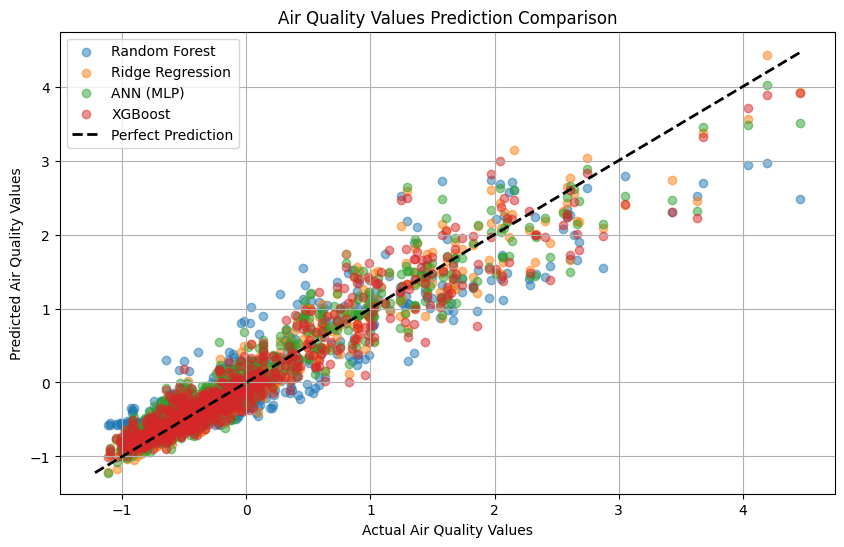

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, rf_model.predict(X_test), alpha=0.5, label='Random Forest')

plt.scatter(y_test, ridge_model.predict(X_test_scaled), alpha=0.5, label='Ridge Regression')

plt.scatter(y_test, ann_model.predict(X_test_scaled), alpha=0.5, label='ANN (MLP)')

plt.scatter(y_test, xgb_model.predict(X_test), alpha=0.5, label='XGBoost')

# Perfect prediction line
min_val = min(y_test.min(), rf_model.predict(X_test).min(), ridge_model.predict(X_test_scaled).min(), ann_model.predict(X_test_scaled).min(), xgb_model.predict(X_test).min())

max_val = max(y_test.max(), rf_model.predict(X_test).max(), ridge_model.predict(X_test_scaled).max(), ann_model.predict(X_test_scaled).max(), xgb_model.predict(X_test).max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Air Quality Values')
plt.ylabel('Predicted Air Quality Values')
plt.title('Air Quality Values Prediction Comparison')
plt.legend()
plt.grid(True)

plt.show()

Observations: The above 4 models all predicted very closely to the actual values though there seems to be a slight edge in overestimating. However, these seem to be the best performing models. They follow a similarish trend to the other plot

21. Calculating the Mean Air Qualityn Value to Get the Percentage Error



In [ ]:
# Mean of the actual air quality values
mean_aq = y_test.mean()
print("Mean air quality value:", mean_aq)

Mean air quality value: -0.010988862472987727


In [ ]:
#RMSE
lr_rmse = np.sqrt(mean_squared_error(y_test, test_pred_lr))
lasso_rmse = np.sqrt(mean_squared_error(y_test, test_pred_lasso))
rf_rmse = np.sqrt(mean_squared_error(y_test, test_pred_rf))
sgd_rmse = np.sqrt(mean_squared_error(y_test, test_pred_sgd))
sgdo_rmse = np.sqrt(mean_squared_error(y_test, test_pred_sgdo))
svr_rmse = np.sqrt(mean_squared_error(y_test, test_pred_svr))
svro_rmse = np.sqrt(mean_squared_error(y_test, test_pred_svro))
ridge_rmse = np.sqrt(mean_squared_error(y_test, test_pred_ridge))
ann_rmse = np.sqrt(mean_squared_error(y_test, test_pred_ann))
xgb_rmse = np.sqrt(mean_squared_error(y_test, test_pred_xgb))

# Mean of actual values
mean_actual = np.mean(y_test)

# Percentage Error
lr_percentage_error = (lr_rmse / mean_actual) * 100
lasso_percentage_error = (lasso_rmse / mean_actual) * 100
rf_percentage_error = (rf_rmse / mean_actual) * 100
sgd_percentage_error = (sgd_rmse / mean_actual) * 100
sgdo_percentage_error = (sgdo_rmse / mean_actual) * 100
svr_percentage_error = (svr_rmse / mean_actual) * 100
svro_percentage_error = (svro_rmse / mean_actual) * 100
ridge_percentage_error = (ridge_rmse / mean_actual) * 100
ann_percentage_error = (ann_rmse / mean_actual) * 100
xgb_percentage_error = (xgb_rmse / mean_actual) * 100

print(f"Linear Regression Percentage Error: {lr_percentage_error:.2f}%")
print(f"Lasso Regression Percentage Error: {lasso_percentage_error:.2f}%")
print(f"Random Forest Percentage Error: {rf_percentage_error:.2f}%")
print(f"SGD Regression Percentage Error: {sgd_percentage_error:.2f}%")
print(f"SGD Regression Optimized Percentage Error: {sgdo_percentage_error:.2f}%")
print(f"SVR Regression Percentage Error: {svr_percentage_error:.2f}%")
print(f"SVR Regression Optimized Percentage Error: {svro_percentage_error:.2f}%")
print(f"Ridge Regression Percentage Error: {ridge_percentage_error:.2f}%")
print(f"Artificial Neural Network Percentage Error: {ann_percentage_error:.2f}%")
print(f"XGB Regression Percentage Error: {xgb_percentage_error:.2f}%")

Linear Regression Percentage Error: -2091.12%
Lasso Regression Percentage Error: -8106.24%
Random Forest Percentage Error: -3227.45%
SGD Regression Percentage Error: -2225.77%
SGD Regression Optimized Percentage Error: -2238.11%
SVR Regression Percentage Error: -2096.39%
SVR Regression Optimized Percentage Error: -2194.09%
Ridge Regression Percentage Error: -2091.28%
Artificial Neural Network Percentage Error: -2250.06%
XGB Regression Percentage Error: -2357.88%


In [ ]:
lr_mae = np.sqrt(mean_absolute_error(y_test, test_pred_lr))
lasso_mae = np.sqrt(mean_absolute_error(y_test, test_pred_lasso))
rf_mae = np.sqrt(mean_absolute_error(y_test, test_pred_rf))
sgd_mae = np.sqrt(mean_absolute_error(y_test, test_pred_sgd))
sgdo_mae = np.sqrt(mean_absolute_error(y_test, test_pred_sgdo))
svr_mae = np.sqrt(mean_absolute_error(y_test, test_pred_svr))
svro_mae = np.sqrt(mean_absolute_error(y_test, test_pred_svro))
ridge_mae = np.sqrt(mean_absolute_error(y_test, test_pred_ridge))
ann_mae = np.sqrt(mean_absolute_error(y_test, test_pred_ann))
xgb_mae = np.sqrt(mean_absolute_error(y_test, test_pred_xgb))

print(f"Linear Regression MAE: {lr_mae:.2f}")
print(f"Lasso Regression MAE: {lasso_mae:.2f}")
print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"SGD Regression MAE: {sgd_mae:.2f}")
print(f"SGD Regression Optimized MAE: {sgdo_mae:.2f}")
print(f"SVR Regression MAE: {svr_mae:.2f}")
print(f"SVR Regression Optimized MAE: {svro_mae:.2f}")
print(f"Ridge Regression MAE {ridge_mae:.2f}")
print(f"Artificial Neural Network MAE: {ann_mae:.2f}")
print(f"XGB Regression MAE: {xgb_mae:.2f}")

Linear Regression MAE: 0.40
Lasso Regression MAE: 0.81
Random Forest MAE: 0.51
SGD Regression MAE: 0.42
SGD Regression Optimized MAE: 0.42
SVR Regression MAE: 0.40
SVR Regression Optimized MAE: 0.42
Ridge Regression MAE 0.40
Artificial Neural Network MAE: 0.42
XGB Regression MAE: 0.43


In [ ]:
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"Lasso Regression RMSE: {lasso_rmse:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"SGD Regression RMSE: {sgd_rmse:.2f}")
print(f"SGD Regression Optimized RMSE: {sgdo_rmse:.2f}")
print(f"SVR Regression RMSE: {svr_rmse:.2f}")
print(f"SVR Regression Optimized RMSE: {svro_rmse:.2f}")
print(f"Ridge Regression RMSE: {ridge_rmse:.2f}")
print(f"Artificial Neural Network RMSE: {ann_rmse:.2f}")
print(f"XGB Regression RMSE: {xgb_rmse:.2f}")

Linear Regression RMSE: 0.23
Lasso Regression RMSE: 0.89
Random Forest RMSE: 0.35
SGD Regression RMSE: 0.24
SGD Regression Optimized RMSE: 0.25
SVR Regression RMSE: 0.23
SVR Regression Optimized RMSE: 0.24
Ridge Regression RMSE: 0.23
Artificial Neural Network RMSE: 0.25
XGB Regression RMSE: 0.26


Plotting RMSE and R squared

In [ ]:
lr_r2 = r2_score(y_test, test_pred_lr)
lasso_r2 = r2_score(y_test, test_pred_lasso)
rf_r2 = r2_score(y_test, test_pred_rf)
sgd_r2 = r2_score(y_test, test_pred_sgd)
sgdo_r2 = r2_score(y_test, test_pred_sgdo)
svr_r2 = r2_score(y_test, test_pred_svr)
svro_r2 = r2_score(y_test, test_pred_svro)
ridge_r2 = r2_score(y_test, test_pred_ridge)
ann_r2 = r2_score(y_test, test_pred_ann)
xgb_r2 = r2_score(y_test, test_pred_xgb)
print(f"Linear Regression R squared: {lr_r2:.2f}")
print(f"Lasso Regression R squared: {lasso_r2:.2f}")
print(f"Random Forest R squared: {rf_r2:.2f}")
print(f"SGD Regression R squared: {sgd_r2:.2f}")
print(f"SGD Regression Optimized R squared: {sgdo_r2:.2f}")
print(f"SVR Regression R squared: {svr_r2:.2f}")
print(f"SVR Regression Optimized R squared: {svro_r2:.2f}")
print(f"Ridge Regression R squared: {ridge_r2:.2f}")
print(f"Artificial Neural Network R squared: {ann_r2:.2f}")
print(f"XGB Regression R squared: {xgb_r2:.2f}")

Linear Regression R squared: 0.93
Lasso Regression R squared: -0.00
Random Forest R squared: 0.84
SGD Regression R squared: 0.92
SGD Regression Optimized R squared: 0.92
SVR Regression R squared: 0.93
SVR Regression Optimized R squared: 0.93
Ridge Regression R squared: 0.93
Artificial Neural Network R squared: 0.92
XGB Regression R squared: 0.92


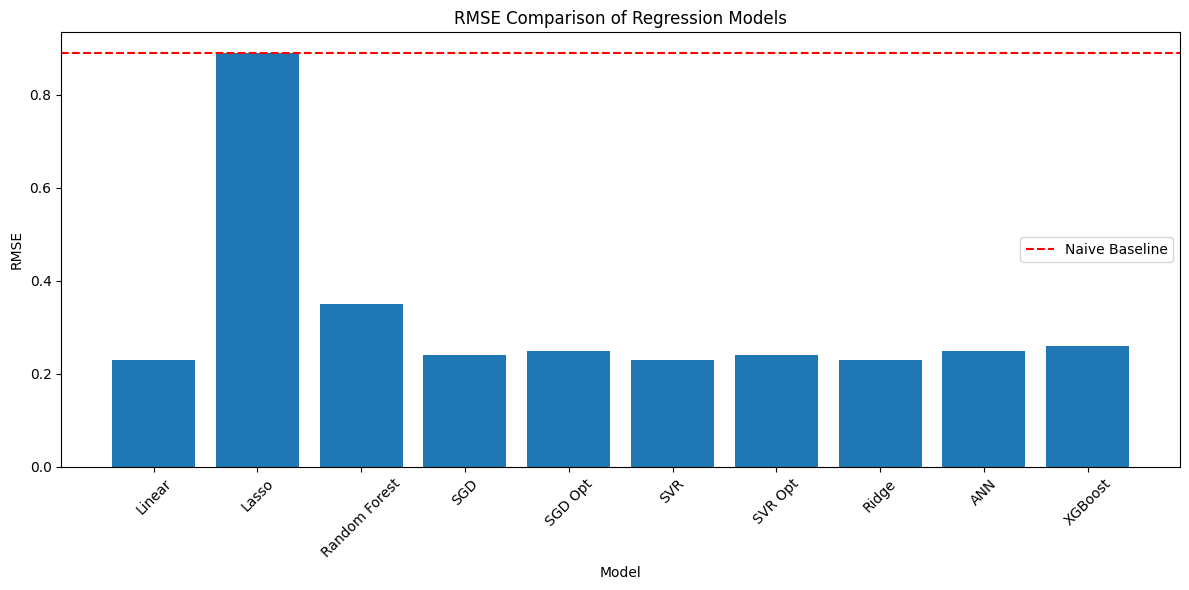

In [ ]:
plot_models = ["Linear", "Lasso", "Random Forest", "SGD", "SGD Opt", "SVR", "SVR Opt", "Ridge", "ANN", "XGBoost"]

rmse = [0.23, 0.89, 0.35, 0.24, 0.25, 0.23, 0.24, 0.23, 0.25, 0.26]

plt.figure(figsize=(12,6))

plt.bar(plot_models, rmse)

plt.axhline(y=0.8907, color='red', linestyle='--', label='Naive Baseline')

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison of Regression Models")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

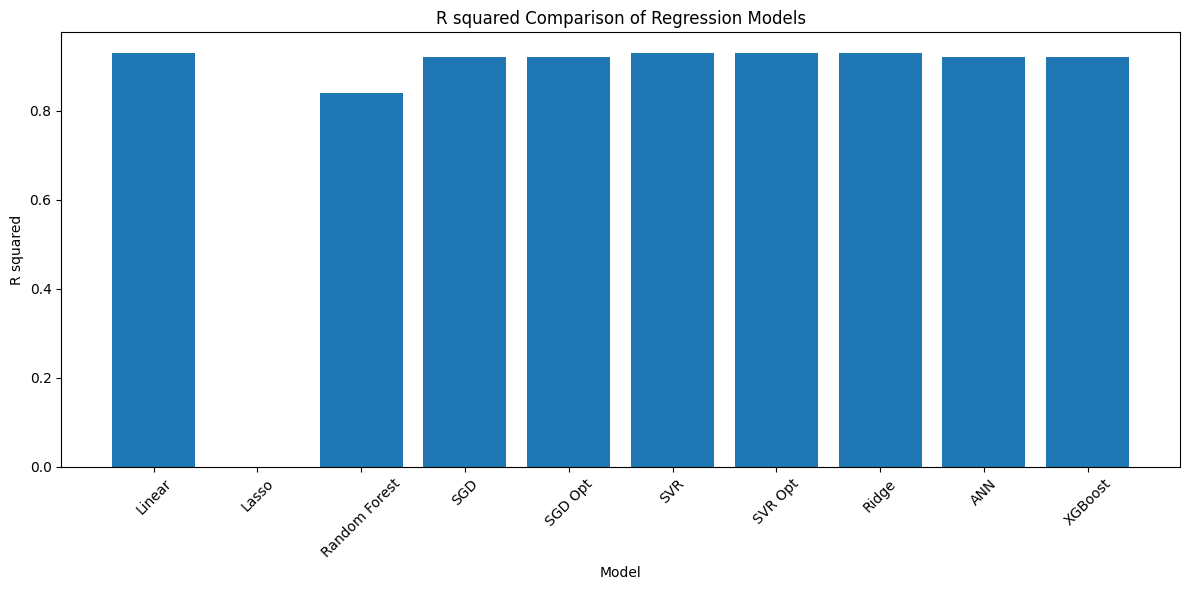

In [ ]:
r2_scores = [0.93, -0.00, 0.84, 0.92, 0.92, 0.93, 0.93, 0.93, 0.92, 0.92]

plt.figure(figsize=(12,6))

plt.bar(plot_models, r2_scores)

plt.ylabel("R squared")

plt.xlabel("Model")

plt.title("R squared Comparison of Regression Models")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Observations: Linear Regression's percentage error being 0 does support that the RMSE and MAE's are super close to 0 and bit too clear, thus wouldn't be used. However, I wasn't expecting most others to have far out error that indicate overestimations. The closest one to 0 aside from Linear Regression would be Ridge Regression, and the next ones would be SGD Optimized, SGD, and XGBoost.

After fixing data leak: all of the values together look much better now. the best performing models are Linear Regression due to being tied for the highest R squared at 0.93 and the lowest MAE and RMSE at 0.40 and 0.23 respectively, Ridge Regression for the same values and being more robust, and SVR Regression having comparable but slightly worse performance. SVR Optimized is a closer runner up but the RMSE and MAE are slightly higher, and the rest had solid performances but fell short.
I pick Ridge Regression as the final model because it's more robust and one of the best models, plus it's good for datasets like these.

22. Calculating the Naive Baseline RMSE to Get the Percentage Error

In [ ]:
naive_baseline_rmse = np.sqrt(mean_squared_error(y_test, [mean_aq] * len(y_test)))
improvement = ((naive_baseline_rmse - 0.23) / naive_baseline_rmse) * 100

print(f"Naive Baseline RMSE: {naive_baseline_rmse:.4f}")
print(f"Ridge RMSE: 0.23")
print(f"Improvement: {improvement:.2f}%")

Naive Baseline RMSE: 0.8907
Ridge RMSE: 0.23
Improvement: 74.18%


23. Feature Importance

In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': ridge_model.coef_})

feature_importance['Absolute Importance'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(by='Absolute Importance', ascending=False)

print(feature_importance)

              Feature  Coefficient  Absolute Importance
9            aq_roll3     1.342178             1.342178
10           aq_roll6    -1.095029             1.095029
11          aq_roll12     0.599182             0.599182
5             aq_lag1    -0.336938             0.336938
6             aq_lag3     0.154336             0.154336
7             aq_lag6     0.150044             0.150044
1           month_sin    -0.032025             0.032025
2           month_cos    -0.015856             0.015856
8            aq_lag12    -0.006762             0.006762
4           longitude     0.003564             0.003564
30         city_Tokyo    -0.002416             0.002416
12        city_Berlin    -0.001448             0.001448
23         city_Paris    -0.001283             0.001283
15         city_Delhi     0.001189             0.001189
16       city_Houston    -0.000810             0.000810
18        city_London    -0.000788             0.000788
13       city_Chicago    -0.000685             0

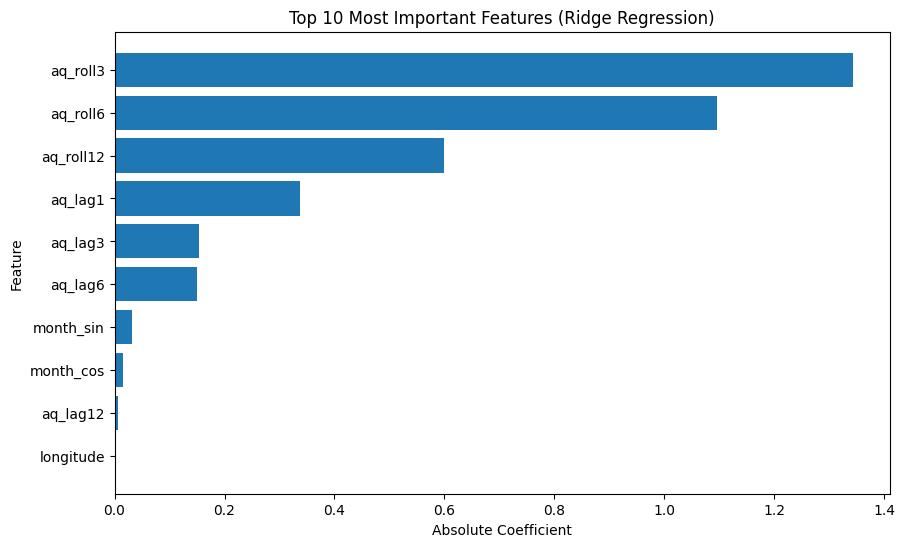

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Absolute Importance'])

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features (Ridge Regression)")

plt.gca().invert_yaxis()
plt.show()

Observations: The rolling averages were by far the most impactful training, with the lag features not being far behind. This makes sense because they are the biggest indicators overall and thus will be used a lot.

Coefficient Importance Plot

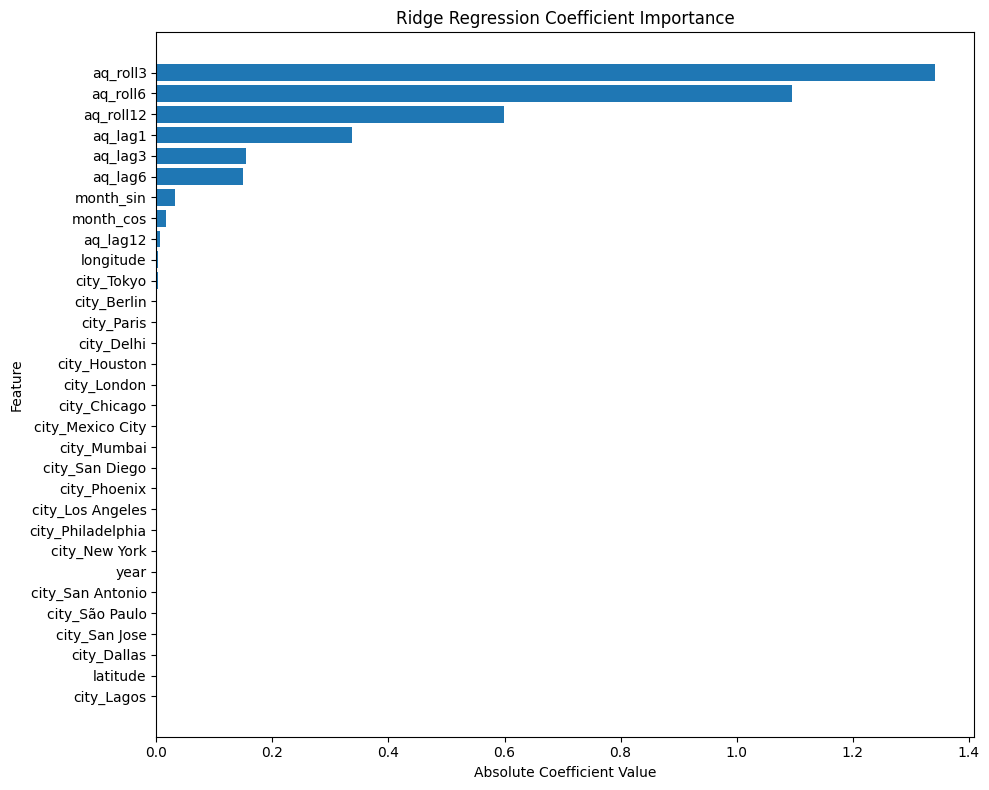

In [ ]:
plot_data = feature_importance.sort_values(by='Absolute Importance', ascending=True)

plt.figure(figsize=(10,8))

plt.barh(plot_data['Feature'], plot_data['Absolute Importance'])

plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

plt.title("Ridge Regression Coefficient Importance")

plt.tight_layout()

plt.show()

24. Plotting the Actual Vs. Predicted Air Quality levels for Ridge Regression

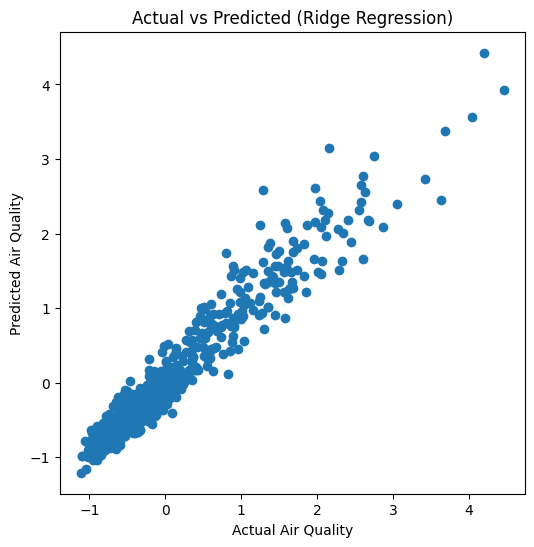

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, test_pred_ridge, alpha=1.0)
plt.xlabel("Actual Air Quality")
plt.ylabel("Predicted Air Quality")
plt.title("Actual vs Predicted (Ridge Regression)")
plt.show()

Observations:

- The Overall Trend Captured Well

The predicted values follow the same general upward trend as the actual air quality values. This indicates that the Ridge Regression model successfully learned the long-term correlations between input values and air quality levels

- The Close Alignment Between Lines

For most of the timeline, the predicted curve stays very close to the actual
curve, which suggests that the model provides reasonably accurate predictions and captures the underlying structure of the data.

- The Small Deviations During Volatile Periods

Some models have some visible gaps between the predicted and actual air quality levels towards higher data values. This is expected because sudden events such as fires or traffic may happen that may hinder air quality levels. However the current models don't have any features that can accurately measure those things


- The Consistent Model Behavior

The predictions do not diverge significantly from the actual air quality levels over time, indicating stable model performance and good generalization across the test dataset.

In conclusion, the visualization shows that the Ridge Regression model captures the general direction and magnitude of air quality levels quite well, although it struggles slightly with sudden short-term fluctuations caused by outside factors. This behavior is expected for a linear model and aligns with the low RMSE values, high R squared and low percentage error during model evaluation.

25. Plotting Residuals

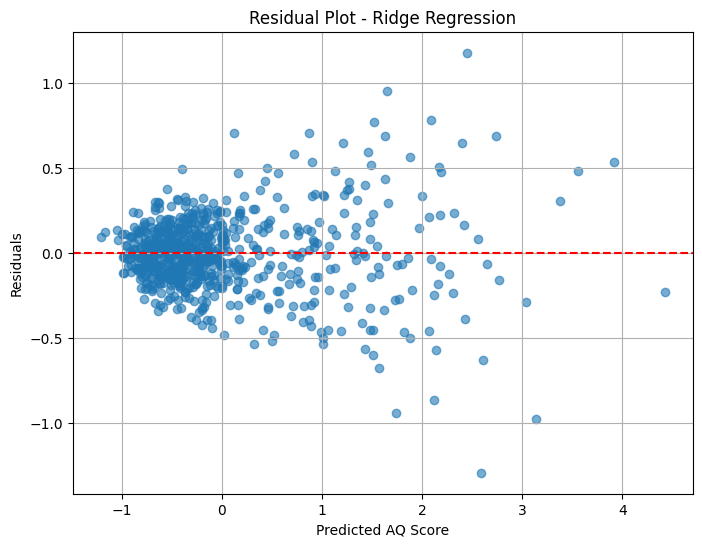

In [ ]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate residuals
ridge_residuals = y_test - y_pred_ridge

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_pred_ridge, ridge_residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted AQ Score")
plt.ylabel("Residuals")
plt.title("Residual Plot - Ridge Regression")

plt.grid(True)
plt.show()

Observations:
The residuals are generally scattered around zero, which indicates a good fit for capturing underlying patterns in the data. Other than that, there isn't really a trend in the residuals which indicates good linear assumptions. However, the residuals getting more scattered as AQ score increases might indicate errors.

Residuals Distribution

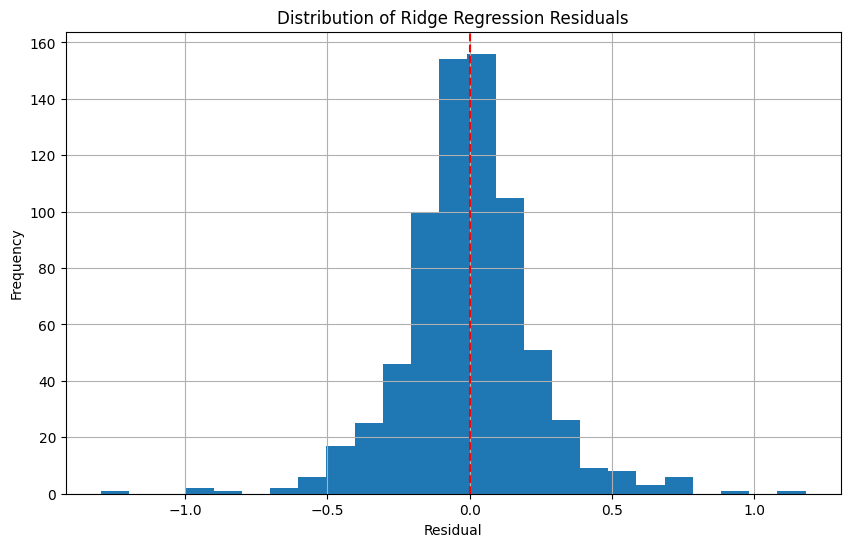

In [ ]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_residuals = y_test - y_pred_ridge

plt.figure(figsize=(10,6))

plt.hist(ridge_residuals, bins=25)

plt.axvline(x=0, color='red', linestyle='--')

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Distribution of Ridge Regression Residuals")

plt.grid(True)

plt.show()

Observations: This shows the residuals are mostly centered around zero in a bell shape, and there's no heavy skew. This is consistent with the residual scatterplot

26. Learning Curve Plot

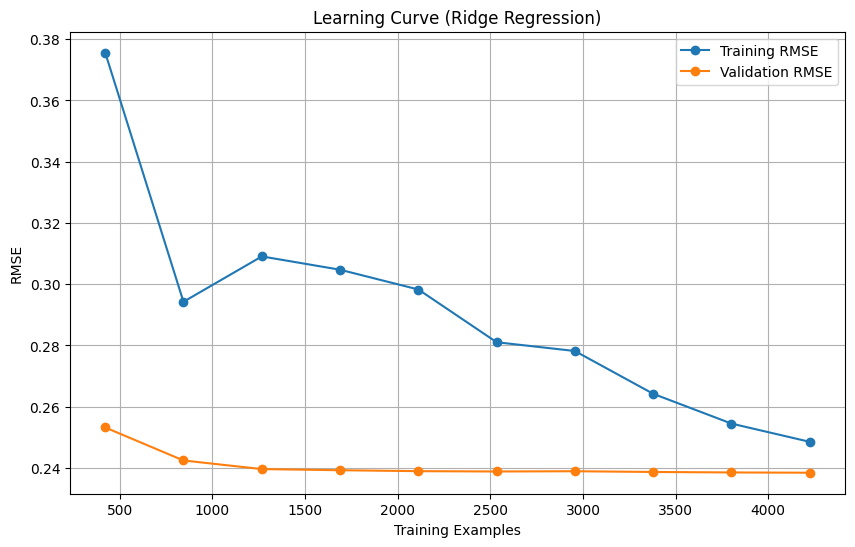

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(estimator=ridge_model, X=X_train_scaled, y=y_train, cv=5, scoring='neg_root_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

lc_train_rmse = -train_scores.mean(axis=1)
lc_validation_rmse = -validation_scores.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(train_sizes, lc_train_rmse, marker='o', label='Training RMSE')

plt.plot(train_sizes, lc_validation_rmse, marker='o', label='Validation RMSE')

plt.xlabel("Training Examples")

plt.ylabel("RMSE")

plt.title("Learning Curve (Ridge Regression)")

plt.legend()

plt.grid(True)

plt.show()

Observations: The Training and Validation RMSE's got close and flattened as more data was used, though there was an initial spike in training RMSE at arount 800 samples

27. Predicting future air quality values

In [ ]:
latest_features = X_test.iloc[[-1]]

# Scale
latest_features_scaled = scaler.transform(latest_features)

# Predict
future_prediction = ridge_model.predict(latest_features_scaled)

print("Predicted Next AQ Score:")
print(future_prediction[0])

Predicted Next AQ Score:
-0.6680561294763808


Observations: The model predicted the AQ score at about -0.668, which is better than average for the standardized AQ score and suggests that next month's air quality will be moderately better than the average air quality in the dataset. Because the AQ score was created by combining standardized PM2.5 and NO2 values, a score of zero represents the dataset average; therefore, a negative score means the expected air quality is better than the average conditions observed in the dataset, while positive scores indicate worse air quality.

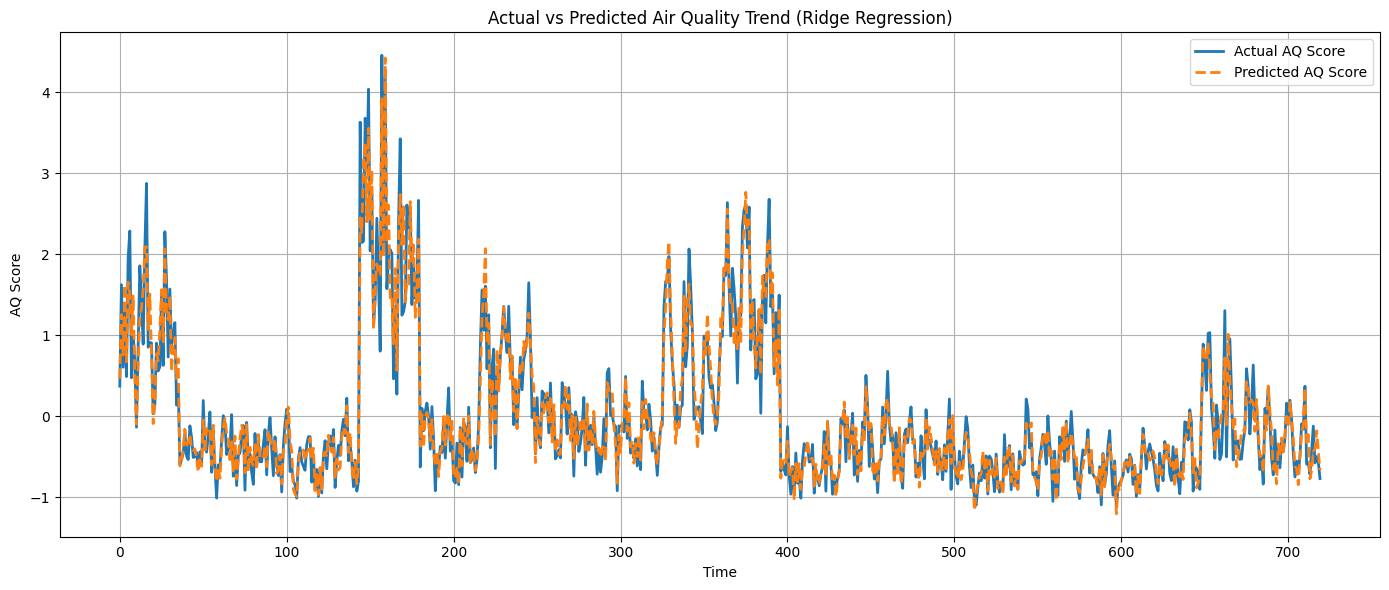

In [ ]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual AQ Score', linewidth=2)

plt.plot(y_pred_ridge, linestyle='--', linewidth=2, label='Predicted AQ Score')

plt.xlabel("Time")
plt.ylabel("AQ Score")
plt.title("Actual vs Predicted Air Quality Trend (Ridge Regression)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Observations: this graph shows that the predicted air quality trends are very close to the actual trends, which would be consistent with the ridge regression model's high performance

28. Future Trend Visualization

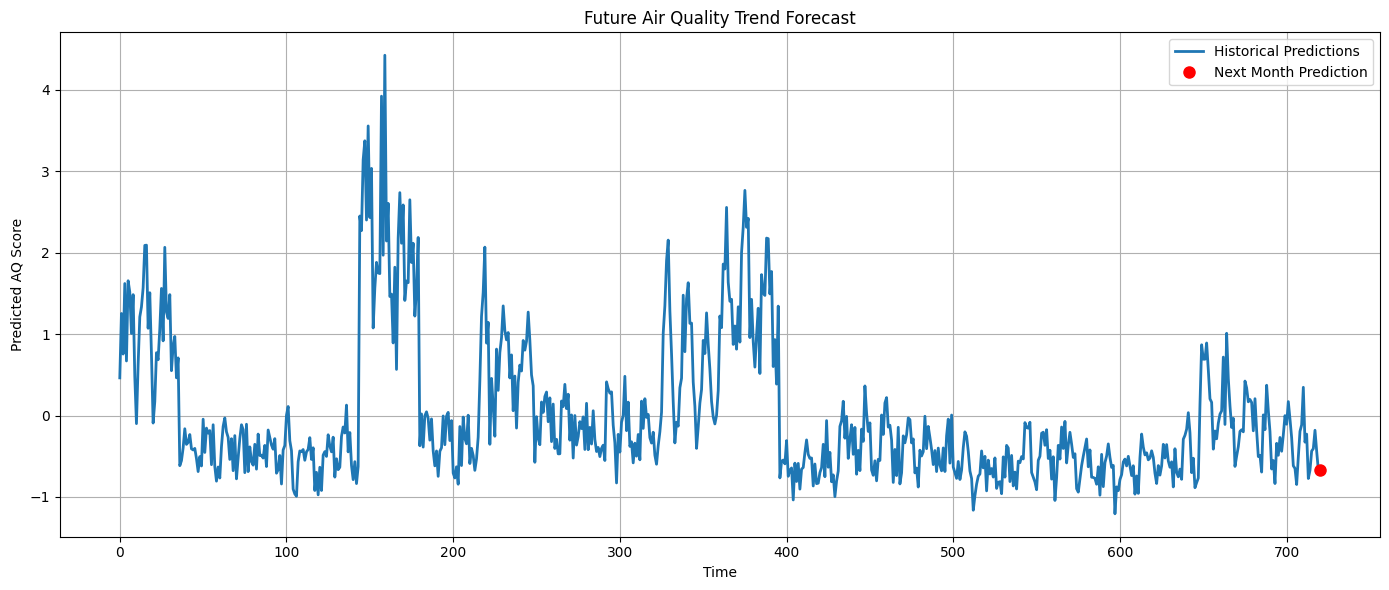

In [ ]:
# Extend prediction by one future point
future_trend = np.append(y_pred_ridge, future_prediction)

# Create x-axis
historical = np.arange(len(y_pred_ridge))
future = np.arange(len(y_pred_ridge), len(y_pred_ridge) + 1)

plt.figure(figsize=(14,6))

# Historical predicted trend
plt.plot(historical, y_pred_ridge, label="Historical Predictions", linewidth=2)

# Future forecast
plt.plot(future, future_prediction, 'ro', markersize=8, label="Next Month Prediction")

# Connect last prediction to future prediction
plt.plot([historical[-1], future[0]], [y_pred_ridge[-1], future_prediction[0]], 'r--')

plt.xlabel("Time")
plt.ylabel("Predicted AQ Score")
plt.title("Future Air Quality Trend Forecast")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()